In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import pandas as pd

# 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/analysis_df.csv')
reviews = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/olist data/olist_order_reviews_dataset.csv')

In [26]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [27]:
reviews = reviews[['order_id', 'review_comment_message']]

df = df.merge(reviews, on='order_id', how='left')

In [28]:
df.columns

Index(['customer_id_x', 'first_order', 'last_order', 'order_count',
       'avg_order_gap', 'reference_date', 'days_since_last', 'churn_90',
       'churn_dynamic', 'total_revenue', 'median_order_gap', 'lifecycle',
       'churn_type', 'behavior', 'value_segment', 'order_id', 'customer_id_y',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'product_category_name', 'review_score', 'is_delayed',
       'review_comment_message'],
      dtype='object')

#Olist 리뷰 NLP

In [29]:
# 1. 텍스트 전처리
import re
import pandas as pd

# 복사본 생성
df_text = df.copy()

# 결측 처리
df_text['review_comment_message'] = df_text['review_comment_message'].fillna('')

# 소문자 변환
df_text['clean_text'] = df_text['review_comment_message'].str.lower()

# 특수문자 제거
df_text['clean_text'] = df_text['clean_text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

# 공백 정리
df_text['clean_text'] = df_text['clean_text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

In [30]:
# 2. 불용어 제거 + 토큰화
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese'))
custom_stopwords = {
    'produto', 'muito', 'bom', 'prazo', 'entrega',
    'recebi', 'chegou', 'com', 'que', 'foi'
}

stop_words = stop_words.union(custom_stopwords)

def preprocess(text):
    text = text.lower()  # 소문자
    text = re.sub(r'[^a-zà-ú\s]', '', text)  # 포르투갈어 문자 포함

    tokens = word_tokenize(text)
    tokens = text.split()

    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

df_text['processed_text'] = df_text['clean_text'].apply(preprocess)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
# 3. TF-IDF 벡터화
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,   # 상위 1000개 단어만
    ngram_range=(1,2),   # unigram + bigram
    min_df=10,            # 최소 등장 횟수
    max_df=0.8           # 너무 흔한 단어 제거
)

X = vectorizer.fit_transform(df_text['processed_text'])

feature_names = vectorizer.get_feature_names_out()

In [32]:
# 4. 세그먼트별 키워드 추출
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def get_top_keywords(df, text_col, segment_col=None, segment_value=None, n=20):

    # 🔥 1. 세그먼트 필터링 추가
    if segment_col is not None and segment_value is not None:
        df = df[df[segment_col] == segment_value]

    texts = df[text_col].dropna()

    from sklearn.feature_extraction.text import TfidfVectorizer
    import numpy as np

    vectorizer = TfidfVectorizer(
        min_df=1,
        max_df=0.95,
        token_pattern=r'(?u)\b\w+\b'
    )

    X = vectorizer.fit_transform(texts)

    words = vectorizer.get_feature_names_out()
    scores = np.asarray(X.mean(axis=0)).ravel()

    top_idx = scores.argsort()[::-1][:n]

    result = []
    for i in top_idx:
        result.append((words[i], round(scores[i], 4)))
        print(words[i], round(scores[i], 4))

    return result

In [16]:
#Early churn 그룹
get_top_keywords(df_text, 'clean_text', 'churn_type', 'Early', 15)

produto 0.0312
o 0.0246
no 0.0218
e 0.0212
muito 0.0211
do 0.0209
bom 0.02
prazo 0.0197
a 0.0165
de 0.0162
recomendo 0.015
entrega 0.015
antes 0.0148
chegou 0.0136
recebi 0.0111


[('produto', np.float64(0.0312)),
 ('o', np.float64(0.0246)),
 ('no', np.float64(0.0218)),
 ('e', np.float64(0.0212)),
 ('muito', np.float64(0.0211)),
 ('do', np.float64(0.0209)),
 ('bom', np.float64(0.02)),
 ('prazo', np.float64(0.0197)),
 ('a', np.float64(0.0165)),
 ('de', np.float64(0.0162)),
 ('recomendo', np.float64(0.015)),
 ('entrega', np.float64(0.015)),
 ('antes', np.float64(0.0148)),
 ('chegou', np.float64(0.0136)),
 ('recebi', np.float64(0.0111))]

In [17]:
#Loyal churn 그룹
get_top_keywords(df_text, 'clean_text', 'churn_type', 'Loyal', 15)

produto 0.0301
o 0.023
e 0.0205
no 0.0205
do 0.0183
prazo 0.0183
bom 0.018
muito 0.0176
a 0.0165
de 0.0157
entrega 0.0145
recomendo 0.0137
antes 0.0121
chegou 0.012
recebi 0.0117


[('produto', np.float64(0.0301)),
 ('o', np.float64(0.023)),
 ('e', np.float64(0.0205)),
 ('no', np.float64(0.0205)),
 ('do', np.float64(0.0183)),
 ('prazo', np.float64(0.0183)),
 ('bom', np.float64(0.018)),
 ('muito', np.float64(0.0176)),
 ('a', np.float64(0.0165)),
 ('de', np.float64(0.0157)),
 ('entrega', np.float64(0.0145)),
 ('recomendo', np.float64(0.0137)),
 ('antes', np.float64(0.0121)),
 ('chegou', np.float64(0.012)),
 ('recebi', np.float64(0.0117))]

In [12]:
# Early vs Loyal 차이
def get_diff_keywords(df, col, val1, val2, top_n=10):
    from sklearn.feature_extraction.text import TfidfVectorizer

    text1 = df[df[col]==val1]['processed_text']
    text2 = df[df[col]==val2]['processed_text']

    vectorizer = TfidfVectorizer(max_features=1000)

    X1 = vectorizer.fit_transform(text1)
    X2 = vectorizer.transform(text2)

    diff = X1.mean(axis=0) - X2.mean(axis=0)

    words = vectorizer.get_feature_names_out()
    scores = diff.A1

    top_idx = scores.argsort()[::-1][:top_n]

    return [(words[i], scores[i]) for i in top_idx]

In [13]:
result = get_diff_keywords(df_text, 'churn_type', 'Early', 'Loyal', 15)

for word, score in result:
    print(f"{word}: {score:.4f}")

antes: 0.0053
compra: 0.0029
bem: 0.0029
satisfeito: 0.0028
entregue: 0.0025
parabns: 0.0021
rpida: 0.0017
dentro: 0.0017
gostei: 0.0017
veio: 0.0017
super: 0.0016
recomendo: 0.0015
dias: 0.0015
obrigado: 0.0015
expectativas: 0.0015


In [14]:
print(len(df_text[df_text['churn_type']=='Early']))
print(len(df_text[df_text['churn_type']=='Loyal']))

84713
4269


In [15]:
#Non-churn 그룹
get_top_keywords(df_text, 'churn_type', 'Non-churn', 15)

[('antes', np.float64(0.017579904577374603)),
 ('recomendo', np.float64(0.017016676738455475)),
 ('timo', np.float64(0.011821689701641278)),
 ('entregue', np.float64(0.011724979234201474)),
 ('excelente', np.float64(0.011162683050669467)),
 ('qualidade', np.float64(0.008960404480115012)),
 ('bem', np.float64(0.008908580743131849)),
 ('gostei', np.float64(0.008776240392166477)),
 ('veio', np.float64(0.008100675164386896)),
 ('rpida', np.float64(0.007993827520207103)),
 ('tudo', np.float64(0.007873797415904313)),
 ('ainda', np.float64(0.006423817750904692)),
 ('super', np.float64(0.0063104807180099885)),
 ('loja', np.float64(0.005889700842527834)),
 ('comprei', np.float64(0.005837691853262787))]

### 세그먼트별 4점 기준 감정분석

In [33]:
df_text['review_group'] = df_text['review_score'].apply(
    lambda x: 'low(<=4)' if x <= 4 else 'high(>4)'
)

In [34]:
import pandas as pd

dist = df_text.groupby(['churn_type', 'review_group']).size().reset_index(name='count')

In [35]:
dist

,churn_type,review_group,count
0,Early,high(>4),38656
1,Early,low(<=4),28454
2,Loyal,high(>4),2514
3,Loyal,low(<=4),1637
4,Non-churn,high(>4),16589
5,Non-churn,low(<=4),9377


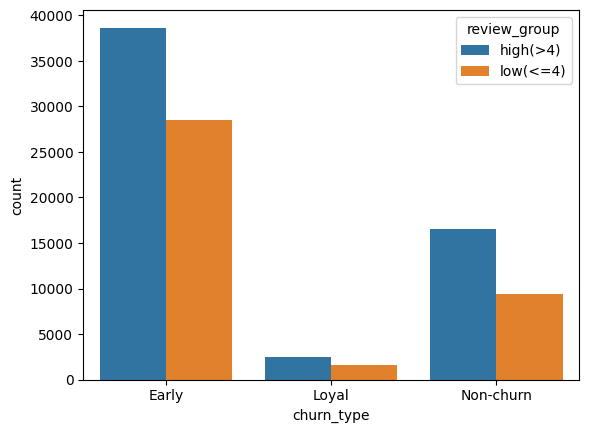

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=dist, x='churn_type', y='count', hue='review_group')
plt.show()

In [37]:
# 그룹별 감정 분석
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df_text['sentiment_score'] = df_text['clean_text'].apply(get_sentiment)

df_text.groupby('churn_type')['sentiment_score']

In [38]:
def sentiment_label(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

df_text['sentiment_label'] = df_text['sentiment_score'].apply(sentiment_label)

sent_dist = (
    df_text
    .groupby(['churn_type', 'sentiment_label'])
    .size()
    .reset_index(name='count')
)

# 비율로 변환
sent_dist['ratio'] = sent_dist.groupby('churn_type')['count'].transform(lambda x: x / x.sum() * 100)

In [39]:
pivot = sent_dist.pivot(index='churn_type', columns='sentiment_label', values='ratio')
print(pivot)

sentiment_label  negative    neutral  positive
churn_type                                    
Early            0.514081  96.446133  3.039785
Loyal            0.505902  96.747772  2.746326
Non-churn        0.350458  96.576292  3.073250


In [49]:
# 그룹별 키워드 분석
# Early + Negative
df_early_neg = df_text[
    (df_text['churn_type']=='Early') &
    (df_text['review_group']=='low(<=4)')
]

df_early_neg = df_early_neg[
    df_early_neg['processed_text'].notna() &
    (df_early_neg['processed_text'].str.strip() != '')
]

print(len(df_early_neg))

get_top_keywords(df_early_neg, 'processed_text', 30)

11119
ainda 0.0351
entregue 0.0289
veio 0.0278
comprei 0.0272
nao 0.0194
pedido 0.0139
compra 0.0131
loja 0.0129
dia 0.0128
qualidade 0.0126
agora 0.0122
produtos 0.012
apenas 0.0119
gostei 0.0115
aguardando 0.0109
recomendo 0.0107
dois 0.0105
porm 0.0104
est 0.01
outro 0.0096
quero 0.0093
nada 0.0093
momento 0.0091
site 0.0089
pois 0.0087
diferente 0.008
bem 0.0079
correios 0.0079
pra 0.0077
duas 0.0077


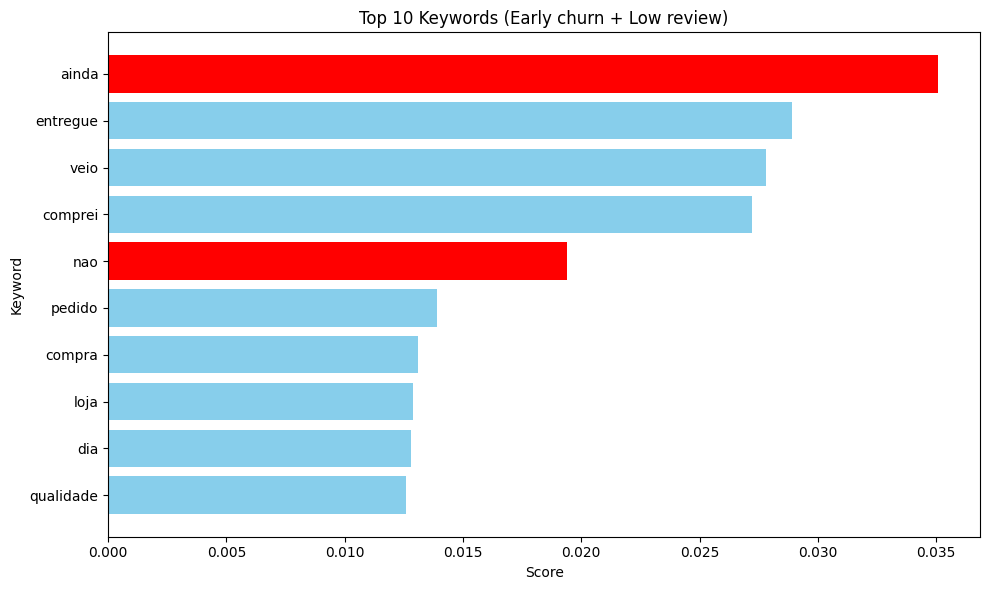

In [61]:
import pandas as pd
import matplotlib.pyplot as plt


data = {
    'keyword': ['ainda','entregue','veio','comprei','nao',
                'pedido','compra','loja','dia','qualidade'],
    'score': [0.0351,0.0289,0.0278,0.0272,0.0194,
              0.0139,0.0131,0.0129,0.0128,0.0126]
}
df_plot = pd.DataFrame(data)
highlight = ['nao', 'ainda', 'aguardando']

df_plot_sorted = df_plot.sort_values(by='score', ascending=True)

colors_sorted = ['red' if k in highlight else 'skyblue'
                 for k in df_plot_sorted['keyword']]

plt.figure(figsize=(10,6))
plt.barh(df_plot_sorted['keyword'],
         df_plot_sorted['score'],
         color=colors_sorted)

plt.title('Top 10 Keywords (Early churn + Low review)')
plt.xlabel('Score')
plt.ylabel('Keyword')

plt.tight_layout()
plt.show()

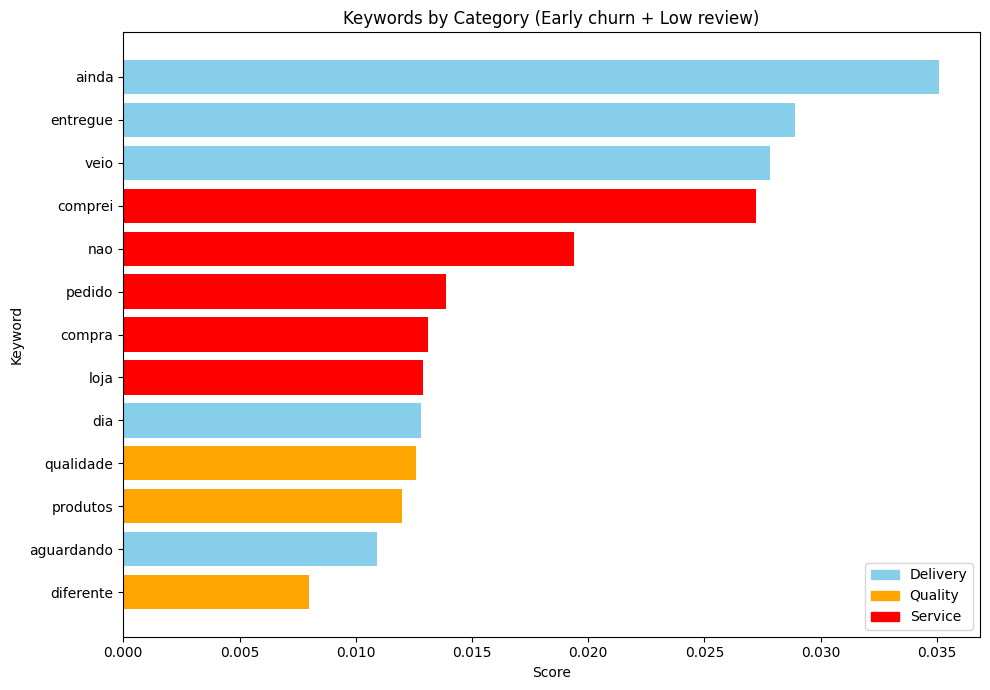

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 🔹 데이터
data = {
    'keyword': [
        'ainda','entregue','veio','comprei','nao','pedido','compra','loja','dia','qualidade',
        'agora','produtos','apenas','gostei','aguardando','recomendo','dois','porm','est','outro',
        'quero','nada','momento','site','pois','diferente','bem','correios','pra','duas'
    ],
    'score': [
        0.0351,0.0289,0.0278,0.0272,0.0194,0.0139,0.0131,0.0129,0.0128,0.0126,
        0.0122,0.012,0.0119,0.0115,0.0109,0.0107,0.0105,0.0104,0.01,0.0096,
        0.0093,0.0093,0.0091,0.0089,0.0087,0.008,0.0079,0.0079,0.0077,0.0077
    ]
}

df = pd.DataFrame(data)

# 🔹 카테고리 정의
delivery_keywords = ['ainda','entregue','veio','dia','aguardando','correios']
quality_keywords = ['qualidade','produtos','diferente']
service_keywords = ['nao','pedido','compra','loja','comprei','apenas']

# 🔹 카테고리 분류
def categorize(word):
    if word in delivery_keywords:
        return 'Delivery'
    elif word in quality_keywords:
        return 'Quality'
    elif word in service_keywords:
        return 'Service'
    else:
        return 'Other'

df['category'] = df['keyword'].apply(categorize)

# 🔹 카테고리별 Top5
df_top5 = (
    df[df['category'] != 'Other']
    .sort_values(['category','score'], ascending=[True, False])
    .groupby('category')
    .head(5)
)

# 🔹 정렬
df_top5 = df_top5.sort_values(by='score')

# 🔹 색상
color_map = {
    'Delivery': 'skyblue',
    'Quality': 'orange',
    'Service': 'red'
}
colors = df_top5['category'].map(color_map)

# 🔹 그래프
plt.figure(figsize=(10,7))
plt.barh(df_top5['keyword'], df_top5['score'], color=colors)

plt.title('Keywords by Category (Early churn + Low review)')
plt.xlabel('Score')
plt.ylabel('Keyword')

# 🔹 legend (핵심!!)
legend_handles = [
    mpatches.Patch(color='skyblue', label='Delivery'),
    mpatches.Patch(color='orange', label='Quality'),
    mpatches.Patch(color='red', label='Service')
]
plt.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

In [33]:
# 그룹별 키워드 분석
# Loyal + Negative
df_early_neg = df_text[
    (df_text['churn_type']=='Loyal') &
    (df_text['review_group']=='low(<=3)')
]

df_early_neg = df_early_neg[
    df_early_neg['processed_text'].notna() &
    (df_early_neg['processed_text'].str.strip() != '')
]

print(len(df_early_neg))

get_top_keywords(df_early_neg, 'processed_text', 30)

520
ainda 0.04
comprei 0.0306
veio 0.03
entregue 0.0269
nao 0.0253
aguardando 0.018
apenas 0.0161
loja 0.0155
defeito 0.0148
produtos 0.0141
dia 0.0132
pedido 0.0127
aguardo 0.0126
pra 0.0125
pois 0.0124
agora 0.0122
devoluo 0.012
outro 0.0119
recomendo 0.0119
site 0.0117
atraso 0.0116
errado 0.0115
unidades 0.0114
gostei 0.0113
dois 0.0113
mercadoria 0.011
momento 0.0109
correios 0.0109
compra 0.0105
est 0.0104


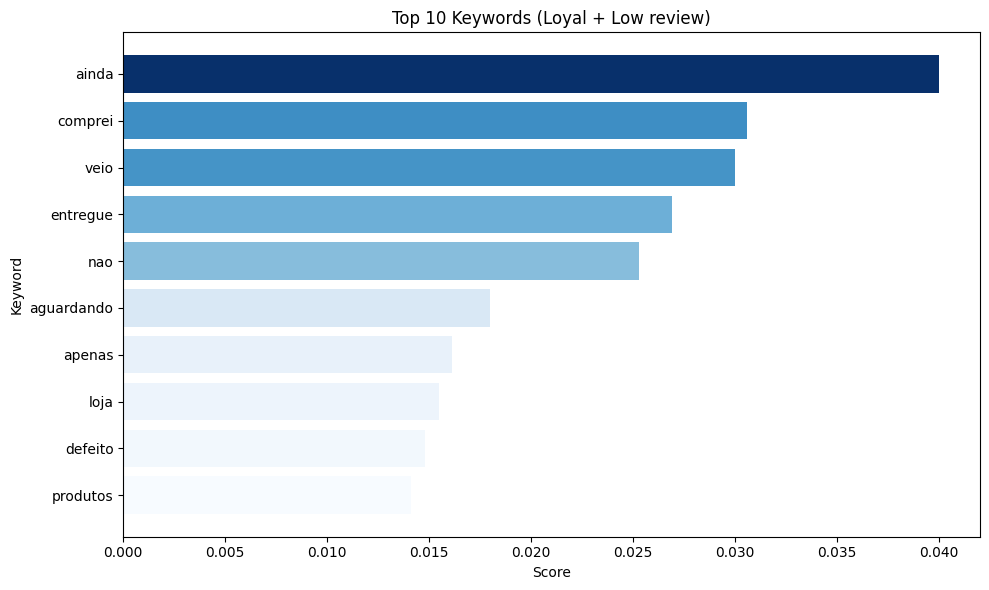

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# 🔹 Top 10 데이터 (네가 뽑은 값 기준)
data = {
    'keyword': ['ainda','comprei','veio','entregue','nao',
                'aguardando','apenas','loja','defeito','produtos'],
    'score': [0.04,0.0306,0.03,0.0269,0.0253,
              0.018,0.0161,0.0155,0.0148,0.0141]
}

df_plot = pd.DataFrame(data)

# 🔹 정렬 (가로 bar용)
df_plot_sorted = df_plot.sort_values(by='score', ascending=True)

# 🔹 score 기반 그라데이션
norm = plt.Normalize(df_plot_sorted['score'].min(),
                     df_plot_sorted['score'].max())

colors = cm.Blues(norm(df_plot_sorted['score']))

# 🔹 그래프
plt.figure(figsize=(10,6))
plt.barh(df_plot_sorted['keyword'],
         df_plot_sorted['score'],
         color=colors)

plt.title('Top 10 Keywords (Loyal + Low review)')
plt.xlabel('Score')
plt.ylabel('Keyword')

plt.tight_layout()
plt.show()

In [35]:
# 그룹별 키워드 분석
# Loyal + positive
df_early_neg = df_text[
    (df_text['churn_type']=='Loyal') &
    (df_text['review_group']=='high(>3)')
]

df_early_neg = df_early_neg[
    df_early_neg['processed_text'].notna() &
    (df_early_neg['processed_text'].str.strip() != '')
]

print(len(df_early_neg))

get_top_keywords(df_early_neg, 'processed_text', 30)

1044
antes 0.0577
recomendo 0.0575
timo 0.039
excelente 0.0375
qualidade 0.0348
tudo 0.0345
entregue 0.0304
bem 0.0247
rpida 0.022
otimo 0.0217
loja 0.0212
gostei 0.0208
amei 0.0199
super 0.0198
boa 0.0179
dentro 0.0176
perfeito 0.0175
tima 0.0174
certo 0.0161
adorei 0.0155
rpido 0.0149
sempre 0.0126
vendedor 0.0121
produtos 0.012
lindo 0.0118
bonito 0.0115
conforme 0.0115
atendimento 0.0114
nota 0.0111
previsto 0.0111


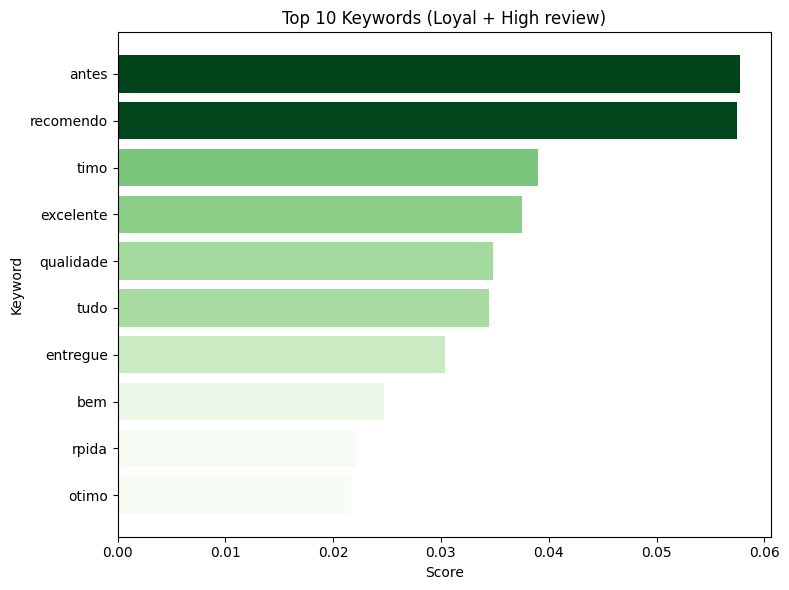

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 🔹 데이터
data = {
    'keyword': [
        'antes','recomendo','timo','excelente','qualidade',
        'tudo','entregue','bem','rpida','otimo',
        'loja','gostei','amei','super','boa'
    ],
    'score': [
        0.0577,0.0575,0.039,0.0375,0.0348,
        0.0345,0.0304,0.0247,0.022,0.0217,
        0.0212,0.0208,0.0199,0.0198,0.0179
    ]
}

df_plot = pd.DataFrame(data)

# 🔹 Top 10만 선택
df_top10 = df_plot.sort_values(by='score', ascending=False).head(10)

# 🔹 다시 정렬 (barh용)
df_top10 = df_top10.sort_values(by='score', ascending=True)

# 🔹 그라데이션 (초록)
norm = plt.Normalize(df_top10['score'].min(),
                     df_top10['score'].max())

colors = cm.Greens(norm(df_top10['score']))

# 🔹 그래프
plt.figure(figsize=(8,6))
plt.barh(df_top10['keyword'],
         df_top10['score'],
         color=colors)

plt.title('Top 10 Keywords (Loyal + High review)')
plt.xlabel('Score')
plt.ylabel('Keyword')

plt.tight_layout()
plt.show()

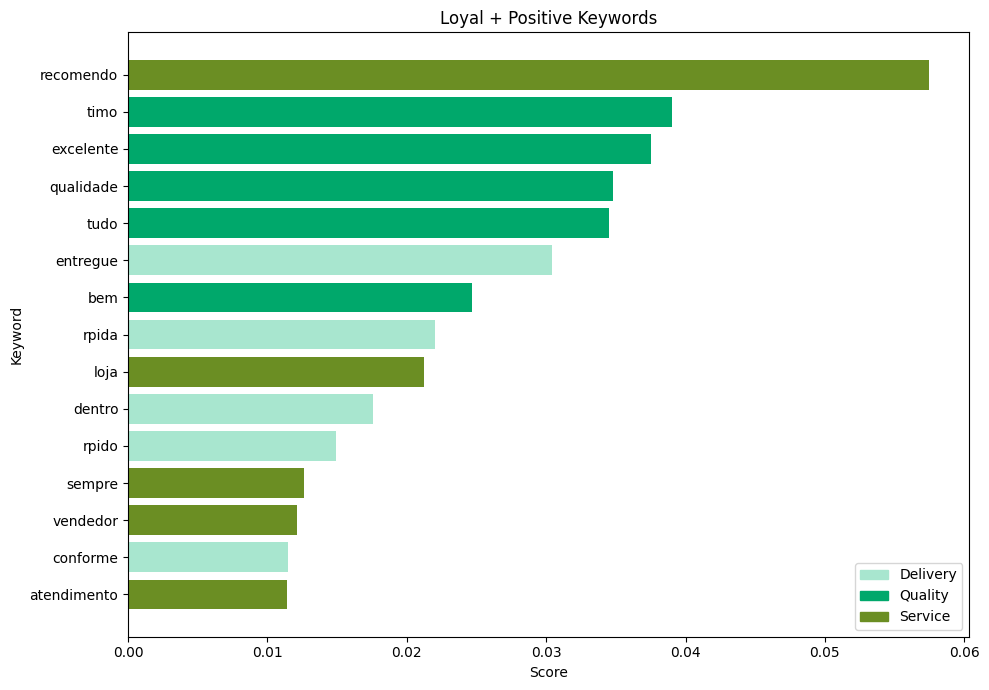

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 🔹 데이터
data = {
    'keyword': [
        'antes','recomendo','timo','excelente','qualidade','tudo','entregue','bem','rpida','otimo',
        'loja','gostei','amei','super','boa','dentro','perfeito','tima','certo','adorei',
        'rpido','sempre','vendedor','produtos','lindo','bonito','conforme','atendimento','nota','previsto'
    ],
    'score': [
        0.0577,0.0575,0.039,0.0375,0.0348,0.0345,0.0304,0.0247,0.022,0.0217,
        0.0212,0.0208,0.0199,0.0198,0.0179,0.0176,0.0175,0.0174,0.0161,0.0155,
        0.0149,0.0126,0.0121,0.012,0.0118,0.0115,0.0115,0.0114,0.0111,0.0111
    ]
}

df = pd.DataFrame(data)

# 🔹 카테고리 정의
delivery_keywords = ['entregue','rpida','rpido','dentro','previsto','conforme']
quality_keywords = ['timo','excelente','qualidade','tudo','bem','otimo','gostei','amei','super',
                    'boa','perfeito','tima','certo','adorei','produtos','lindo','bonito','nota']
service_keywords = ['recomendo','loja','sempre','vendedor','atendimento']

# 🔹 카테고리 분류
def categorize(word):
    if word in delivery_keywords:
        return 'Delivery'
    elif word in quality_keywords:
        return 'Quality'
    elif word in service_keywords:
        return 'Service'
    else:
        return 'Other'

df['category'] = df['keyword'].apply(categorize)

# 🔹 카테고리별 Top5
df_top5 = (
    df[df['category'] != 'Other']
    .sort_values(['category','score'], ascending=[True, False])
    .groupby('category')
    .head(5)
)

df_top5 = df_top5.sort_values(by='score')

# 🔹 ✅ 긍정 전용 컬러 (Green 계열)
color_map = {
    'Delivery': '#A8E6CF',   # 연한 민트
    'Quality': '#00A86B',    # 진한 그린
    'Service': '#6B8E23'     # 올리브
}

colors = df_top5['category'].map(color_map)

# 🔹 그래프
plt.figure(figsize=(10,7))
plt.barh(df_top5['keyword'], df_top5['score'], color=colors)

plt.title('Loyal + Positive Keywords')
plt.xlabel('Score')
plt.ylabel('Keyword')

# 🔹 legend
legend_handles = [
    mpatches.Patch(color='#A8E6CF', label='Delivery'),
    mpatches.Patch(color='#00A86B', label='Quality'),
    mpatches.Patch(color='#6B8E23', label='Service')
]
plt.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

In [36]:
# Non-churn + Negative
df_early_neg = df_text[
    (df_text['churn_type']=='Non-churn') &
    (df_text['review_group']=='low(<=3)')
]

df_early_neg = df_early_neg[
    df_early_neg['processed_text'].notna() &
    (df_early_neg['processed_text'].str.strip() != '')
]

print(len(df_early_neg))

get_top_keywords(df_early_neg, 'processed_text', 30)

860
ainda 0.0385
veio 0.0326
entregue 0.0313
comprei 0.0286
nao 0.0193
dia 0.0168
pedido 0.0164
dois 0.0152
apenas 0.0144
loja 0.0142
compra 0.0139
qualidade 0.0131
outro 0.0127
produtos 0.0121
diferente 0.0117
defeito 0.0112
nada 0.0107
pois 0.0104
quero 0.0102
nota 0.0102
momento 0.0101
recomendo 0.0101
foto 0.0095
aguardando 0.0093
agora 0.0092
est 0.009
cor 0.0089
bem 0.0088
dias 0.0087
frete 0.0086


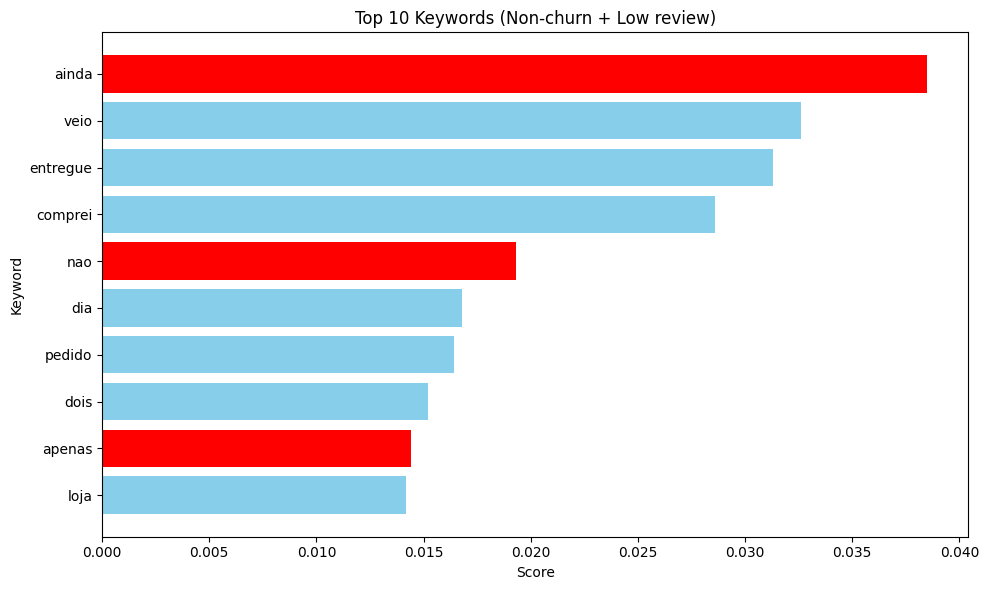

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 데이터 (상위 10개만)
data = {
    'keyword': [
        'ainda','veio','entregue','comprei','nao',
        'dia','pedido','dois','apenas','loja'
    ],
    'score': [
        0.0385,0.0326,0.0313,0.0286,0.0193,
        0.0168,0.0164,0.0152,0.0144,0.0142
    ]
}

df_plot = pd.DataFrame(data)

# 🔹 강조할 키워드 (품질 문제 강조)
highlight = ['nao', 'ainda', 'apenas']

# 🔹 정렬 (barh용)
df_plot_sorted = df_plot.sort_values(by='score', ascending=True)

# 🔹 색상 (highlight만 빨간색)
colors_sorted = [
    'red' if k in highlight else 'skyblue'
    for k in df_plot_sorted['keyword']
]

# 🔹 그래프
plt.figure(figsize=(10,6))
plt.barh(df_plot_sorted['keyword'],
         df_plot_sorted['score'],
         color=colors_sorted)

plt.title('Top 10 Keywords (Non-churn + Low review)')
plt.xlabel('Score')
plt.ylabel('Keyword')

plt.tight_layout()
plt.show()

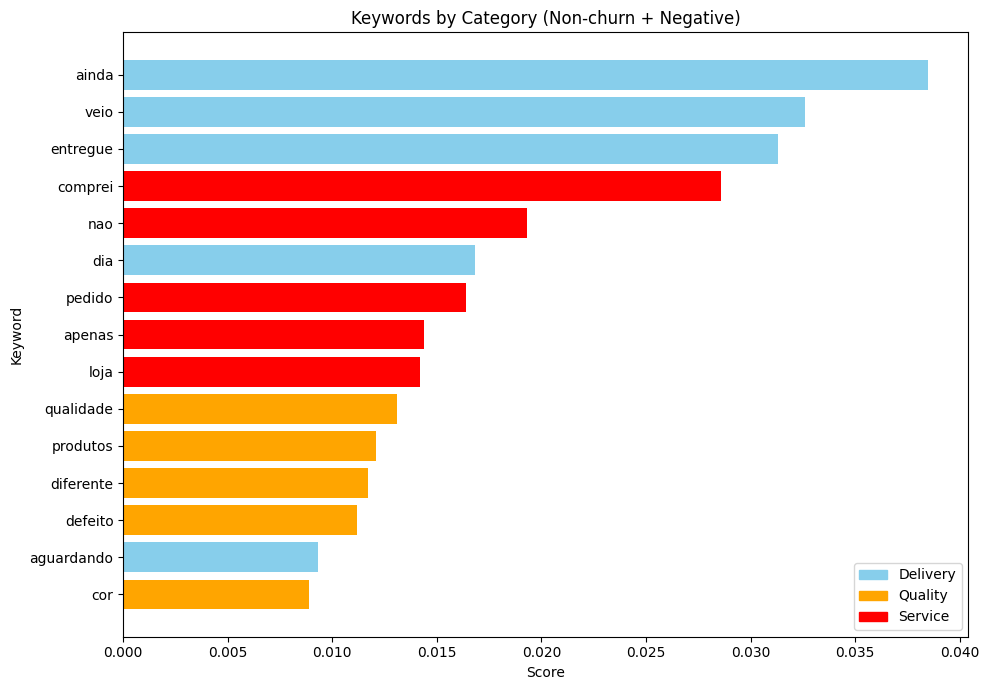

In [73]:
# 불만 원인 카테고리별 시각화
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# 🔹 전체 데이터
data = {
    'keyword': [
        'ainda','veio','entregue','comprei','nao','dia','pedido','dois','apenas','loja',
        'compra','qualidade','outro','produtos','diferente','defeito','nada','pois','quero','nota',
        'momento','recomendo','foto','aguardando','agora','est','cor','bem','dias','frete'
    ],
    'score': [
        0.0385,0.0326,0.0313,0.0286,0.0193,0.0168,0.0164,0.0152,0.0144,0.0142,
        0.0139,0.0131,0.0127,0.0121,0.0117,0.0112,0.0107,0.0104,0.0102,0.0102,
        0.0101,0.0101,0.0095,0.0093,0.0092,0.009,0.0089,0.0088,0.0087,0.0086
    ]
}

df = pd.DataFrame(data)

# 🔹 카테고리 정의
delivery_keywords = ['ainda','veio','entregue','dia','dias','frete','aguardando']
quality_keywords = ['qualidade','defeito','diferente','cor','produtos']
service_keywords = ['nao','pedido','apenas','loja','compra','comprei']

# 🔹 카테고리 컬럼 생성
def categorize(word):
    if word in delivery_keywords:
        return 'Delivery'
    elif word in quality_keywords:
        return 'Quality'
    elif word in service_keywords:
        return 'Service'
    else:
        return 'Other'

df['category'] = df['keyword'].apply(categorize)

# 🔹 카테고리별 Top 5
df_top5 = (
    df[df['category'] != 'Other']
    .sort_values(['category','score'], ascending=[True, False])
    .groupby('category')
    .head(5)
)

# 🔹 정렬 (그래프용)
df_top5 = df_top5.sort_values(by='score')

# 🔹 색상 지정
color_map = {
    'Delivery': 'skyblue',
    'Quality': 'orange',
    'Service': 'red'
}
colors = df_top5['category'].map(color_map)

# 🔹 그래프
plt.figure(figsize=(10,7))
plt.barh(df_top5['keyword'], df_top5['score'], color=colors)

plt.title('Keywords by Category (Non-churn + Negative)')
plt.xlabel('Score')
plt.ylabel('Keyword')

# 🔹 범례 추가
delivery_patch = mpatches.Patch(color='skyblue', label='Delivery')
quality_patch = mpatches.Patch(color='orange', label='Quality')
service_patch = mpatches.Patch(color='red', label='Service')

plt.legend(handles=[delivery_patch, quality_patch, service_patch])

plt.tight_layout()
plt.show()

In [37]:
# Non-churn + Positive
df_early_neg = df_text[
    (df_text['churn_type']=='Non-churn') &
    (df_text['review_group']=='high(>3)')
]

df_early_neg = df_early_neg[
    df_early_neg['processed_text'].notna() &
    (df_early_neg['processed_text'].str.strip() != '')
]

print(len(df_early_neg))

get_top_keywords(df_early_neg, 'processed_text', 30)

2142
antes 0.0618
recomendo 0.0593
timo 0.0434
excelente 0.0411
entregue 0.0339
rpida 0.0303
qualidade 0.0294
gostei 0.0291
bem 0.0291
tudo 0.0281
super 0.0264
boa 0.0192
otimo 0.0192
rpido 0.0188
loja 0.0181
dentro 0.0159
perfeito 0.0157
compra 0.0154
veio 0.0143
tima 0.0142
adorei 0.0137
conforme 0.0135
previsto 0.0125
satisfeita 0.0124
amei 0.012
parabns 0.0115
lindo 0.0114
embalado 0.0113
certo 0.0109
sempre 0.0108


   Category   Negative   Positive
0  Delivery  41.666667  26.666667
1   Quality  16.666667  53.333333
2   Service  41.666667  20.000000


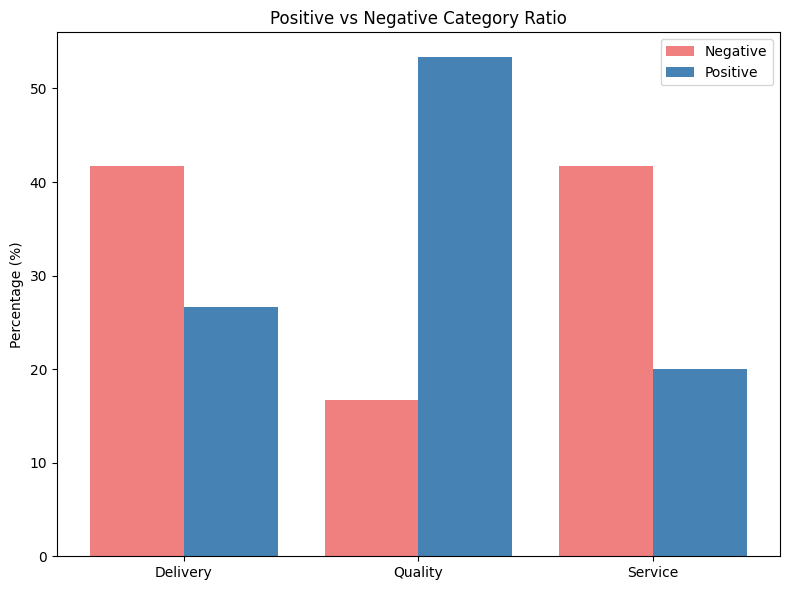

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 🔹 Negative 데이터
# ---------------------------
neg_data = {
    'keyword': [
        'ainda','entregue','veio','comprei','nao','pedido','compra','loja','dia','qualidade',
        'agora','produtos','apenas','gostei','aguardando','recomendo','dois','porm','est','outro',
        'quero','nada','momento','site','pois','diferente','bem','correios','pra','duas'
    ]
}

df_neg = pd.DataFrame(neg_data)

# ---------------------------
# 🔹 Positive 데이터
# ---------------------------
pos_data = {
    'keyword': [
        'antes','recomendo','timo','excelente','qualidade','tudo','entregue','bem','rpida','otimo',
        'loja','gostei','amei','super','boa','dentro','perfeito','tima','certo','adorei',
        'rpido','sempre','vendedor','produtos','lindo','bonito','conforme','atendimento','nota','previsto'
    ]
}

df_pos = pd.DataFrame(pos_data)

# ---------------------------
# 🔹 카테고리 정의
# ---------------------------
delivery_keywords = ['entregue','veio','dia','aguardando','correios','rpido','rpida','previsto']
quality_keywords = ['qualidade','produtos','excelente','otimo','perfeito','boa','lindo','bonito']
service_keywords = ['nao','pedido','compra','loja','comprei','atendimento','vendedor']

def categorize(word):
    if word in delivery_keywords:
        return 'Delivery'
    elif word in quality_keywords:
        return 'Quality'
    elif word in service_keywords:
        return 'Service'
    else:
        return 'Other'

# ---------------------------
# 🔹 카테고리 분류
# ---------------------------
df_neg['category'] = df_neg['keyword'].apply(categorize)
df_pos['category'] = df_pos['keyword'].apply(categorize)

# ---------------------------
# 🔹 비율 계산 함수
# ---------------------------
def get_ratio(df):
    counts = df[df['category'] != 'Other']['category'].value_counts()
    ratio = counts / counts.sum() * 100
    return ratio

neg_ratio = get_ratio(df_neg)
pos_ratio = get_ratio(df_pos)

# ---------------------------
# 🔹 하나의 데이터프레임으로 합치기
# ---------------------------
df_compare = pd.DataFrame({
    'Negative': neg_ratio,
    'Positive': pos_ratio
}).fillna(0)

df_compare = df_compare.reset_index()
df_compare.columns = ['Category', 'Negative', 'Positive']

print(df_compare)

# ---------------------------
# 🔹 시각화
# ---------------------------
x = range(len(df_compare))

plt.figure(figsize=(8,6))

plt.bar(x, df_compare['Negative'], width=0.4, label='Negative',  color='lightcoral')
plt.bar([i + 0.4 for i in x], df_compare['Positive'], width=0.4, label='Positive', color='steelblue')

plt.xticks([i + 0.2 for i in x], df_compare['Category'])
plt.ylabel('Percentage (%)')
plt.title('Positive vs Negative Category Ratio')

plt.legend()
plt.tight_layout()
plt.show()